### Contexto
Breve explicação de qual é o problema e o que buscamos resolver.

### Imports
Explicar quais bibliotecas estamos usando e o porquê.

In [310]:
import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [311]:
import sys
sys.path.append("..")

In [312]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from src.model import criar_modelo
import numpy as np
from sklearn.metrics import confusion_matrix

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


### Exploração dos dados
Etapa para analisar as principais características de um conjunto de dados, identificando padrões, tendências e anomalias.

In [313]:
import pandas as pd

In [314]:
url = "https://raw.githubusercontent.com/AnaElisaMueller/rna/main/data/healthcare_fraud_detection_v1.xlsx"
df = pd.read_excel(url)

In [315]:
df.describe()

,É Fraude,Idade do Paciente,Código do Procedimento,Valor da Solicitação,Valor Aprovado,Data de Envio da Solicitação,Dias Entre o Atendimento e a Solicitação,Número de Solicitações por Prestador (Mensal),Unnamed: 14,Tempo de Internação,Indicador de Condição Crônica,Visitas Anteriores nos Últimos 12 Meses
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000,10000.000000,10000.000000,0.0,10000.00000,10000.000000,9650.000000
mean,0.082900,49.755000,86905.21170,572.804406,475.514157,2023-01-10 02:13:12,14.413800,68.628000,NaN,2.19930,0.292000,3.026425
min,0.000000,1.000000,36415.00000,60.210000,50.350000,2021-01-06 00:00:00,0.000000,42.000000,NaN,0.00000,0.000000,0.000000
25%,0.000000,37.750000,80053.00000,305.205000,257.200000,2022-01-13 00:00:00,7.000000,60.000000,NaN,1.00000,0.000000,2.000000
50%,0.000000,50.000000,93000.00000,461.225000,388.370000,2023-01-03 00:00:00,14.000000,66.000000,NaN,2.00000,0.000000,3.000000
75%,0.000000,62.000000,99213.00000,711.365000,598.347500,2024-01-05 00:00:00,22.000000,72.000000,NaN,3.00000,1.000000,4.000000
max,1.000000,95.000000,99214.00000,6590.700000,4270.890000,2025-01-26 00:00:00,29.000000,144.000000,NaN,5.00000,1.000000,12.000000
std,0.275745,17.910144,14965.32496,406.202437,323.257165,NaN,8.489875,14.905872,NaN,1.71046,0.454705,1.722789


In [316]:
#Remoção de coluna vazia
df = df.drop(columns=['Unnamed: 14'])

In [317]:
#Verificação de nulos por coluna

print("Número de valores nulos por coluna:")
display(df.isnull().sum())

print("Total de valores nulos no DataFrame:")
print(df.isnull().sum().sum())

Número de valores nulos por coluna:


É Fraude                                           0
Idade do Paciente                                  0
Gênero do Paciente                                 0
Código de Diagnóstico                              0
Código do Procedimento                             0
Valor da Solicitação                               0
Valor Aprovado                                     0
Tipo de Seguro                                   350
Data de Envio da Solicitação                       0
Dias Entre o Atendimento e a Solicitação           0
Número de Solicitações por Prestador (Mensal)      0
Especialidade do Prestador                       350
Estado do Paciente                                 0
Status da Solicitação                              0
Tempo de Internação                                0
Tipo de Visita                                     0
Indicador de Condição Crônica                      0
Visitas Anteriores nos Últimos 12 Meses          350
dtype: int64

Total de valores nulos no DataFrame:
1050


#####Exploração dos valores possíveis em colunas categóricas

In [318]:
distinct_specialties = df['Especialidade do Prestador'].unique().copy()
print("Valores distintos da coluna 'Especialidade do Prestador':")
distinct_specialties

Valores distintos da coluna 'Especialidade do Prestador':


<StringArray>
[       'Cardiology',  'General Practice',       'Pulmonology',
       'Orthopedics',                 nan, 'Internal Medicine',
         'Neurology']
Length: 7, dtype: str

In [319]:
tipo_seguro = df['Tipo de Seguro'].unique().copy()
print("Valores distintos da coluna 'Tipo de Seguro':")
tipo_seguro

Valores distintos da coluna 'Tipo de Seguro':


<StringArray>
['Medicaid', 'Self-Pay', 'Private', 'Medicare', nan]
Length: 5, dtype: str

#####Contagem agrupada para posterior tratamento de nulos

In [320]:
count_tipo_seguro = df['Tipo de Seguro'].value_counts().copy()
print("Contagem de valores distintos da coluna 'Tipo de Seguro':")
count_tipo_seguro

Contagem de valores distintos da coluna 'Tipo de Seguro':


Tipo de Seguro
Medicare    2425
Medicaid    2419
Private     2405
Self-Pay    2401
Name: count, dtype: int64

In [321]:
count_especialidades = df['Especialidade do Prestador'].value_counts().copy()
print("Contagem de valores distintos da coluna 'Especialidade do Prestador':")
count_especialidades

Contagem de valores distintos da coluna 'Especialidade do Prestador':


Especialidade do Prestador
Internal Medicine    2019
General Practice     1878
Orthopedics          1616
Neurology            1516
Cardiology           1366
Pulmonology          1255
Name: count, dtype: int64

In [322]:
df_nulls = df[df.isnull().any(axis=1)]
df_nulls

,É Fraude,Idade do Paciente,Gênero do Paciente,Código de Diagnóstico,Código do Procedimento,Valor da Solicitação,Valor Aprovado,Tipo de Seguro,Data de Envio da Solicitação,Dias Entre o Atendimento e a Solicitação,Número de Solicitações por Prestador (Mensal),Especialidade do Prestador,Estado do Paciente,Status da Solicitação,Tempo de Internação,Tipo de Visita,Indicador de Condição Crônica,Visitas Anteriores nos Últimos 12 Meses
7,1,1,Male,I10,85025,934.34,321.60,NaN,2022-07-13,6,114,NaN,PA,Pending,2,Emergency,0,NaN
14,0,4,Female,F41.9,99213,672.35,571.14,Self-Pay,2021-12-20,16,73,NaN,PA,Pending,2,Inpatient,1,4.0
20,0,64,Female,F41.9,99213,181.15,163.55,Self-Pay,2025-01-05,12,80,NaN,PA,Approved,3,Outpatient,1,3.0
23,0,33,Female,E78.5,99213,289.35,286.53,Medicare,2022-04-28,23,65,NaN,IL,Approved,5,Inpatient,1,2.0
26,0,54,Male,K21.9,93000,290.15,259.90,Medicare,2024-03-27,2,73,General Practice,PA,Approved,1,Emergency,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9948,0,56,Female,M54.5,97110,2461.19,1855.08,Medicare,2024-08-18,25,107,Internal Medicine,CA,Approved,2,Emergency,0,NaN
9972,0,80,Male,E78.5,87086,1234.34,1029.42,Self-Pay,2022-08-06,28,66,NaN,NY,Approved,3,Outpatient,0,4.0
9978,0,50,Female,J18.9,36415,367.70,343.99,Medicare,2022-04-23,11,72,NaN,CA,Approved,2,Emergency,0,4.0
9989,0,44,Female,M54.5,97110,737.72,700.09,NaN,2024-08-24,20,45,Neurology,TX,Approved,0,Inpatient,0,2.0


Verificação de compatibilidade de casos em que a coluna ['Visitas Anteriores nos  Últimos 12 Meses'] foi preenchida com 0 e de quando não foi preenchida.

In [323]:
import pandas as pd
import numpy as np


# Isso vai dividir o dataset em três grupos: quem tem 0, quem tem NaN e quem tem 1 ou mais visitas.
condicoes = [
    df['Visitas Anteriores nos Últimos 12 Meses'] == 0,
    df['Visitas Anteriores nos Últimos 12 Meses'].isna(),
    df['Visitas Anteriores nos Últimos 12 Meses'] > 0
]
valores = ['Grupo_Zero', 'Grupo_NaN', 'Grupo_Com_Visitas']

df['Grupo_Analise'] = np.select(condicoes, valores, default='Outros')

# 2. Avaliar variáveis numéricas (Idade, Tempo de Internação, etc.)
print("--- Média de Idade e Tempo de Internação por Grupo ---")
analise_numerica = df.groupby('Grupo_Analise')[['Idade do Paciente', 'Tempo de Internação']].mean()
print(analise_numerica)
print("\n" + "="*50 + "\n")

# 3. Avaliar variáveis categóricas cruciais (Condição Crônica e Tipo de Visita)
print("--- Proporção de Condições Crônicas por Grupo (%) ---")
# Mostra a porcentagem de pacientes com condição crônica dentro de cada grupo
cronicos_por_grupo = pd.crosstab(df['Grupo_Analise'], df['Indicador de Condição Crônica'], normalize='index') * 100
print(cronicos_por_grupo)
print("\n" + "="*50 + "\n")

print("--- Distribuição do Tipo de Visita por Grupo (%) ---")
visita_por_grupo = pd.crosstab(df['Grupo_Analise'], df['Tipo de Visita'], normalize='index') * 100
print(visita_por_grupo)

# Limpeza da coluna temporária após a análise
df.drop(columns=['Grupo_Analise'], inplace=True)

--- Média de Idade e Tempo de Internação por Grupo ---
                   Idade do Paciente  Tempo de Internação
Grupo_Analise                                            
Grupo_Com_Visitas          49.754189             2.198150
Grupo_NaN                  49.640000             2.302857
Grupo_Zero                 49.858696             2.143478


--- Proporção de Condições Crônicas por Grupo (%) ---
Indicador de Condição Crônica          0          1
Grupo_Analise                                      
Grupo_Com_Visitas              70.794342  29.205658
Grupo_NaN                      70.571429  29.428571
Grupo_Zero                     71.086957  28.913043


--- Distribuição do Tipo de Visita por Grupo (%) ---
Tipo de Visita     Emergency  Inpatient  Outpatient
Grupo_Analise                                      
Grupo_Com_Visitas  33.710555  32.132753   34.156692
Grupo_NaN          32.857143  31.142857   36.000000
Grupo_Zero         33.695652  31.956522   34.347826


C:\Users\tbastosdeoli\AppData\Local\Temp\ipykernel_27664\1139130705.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=analise_numerica, x='Grupo Analise', y='Idade do Paciente', ax=axes[0, 0], palette='Blues_r', order=ordem_presente)
C:\Users\tbastosdeoli\AppData\Local\Temp\ipykernel_27664\1139130705.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=analise_numerica, x='Grupo Analise', y='Tempo de Internação', ax=axes[0, 1], palette='Oranges_r', order=ordem_presente)


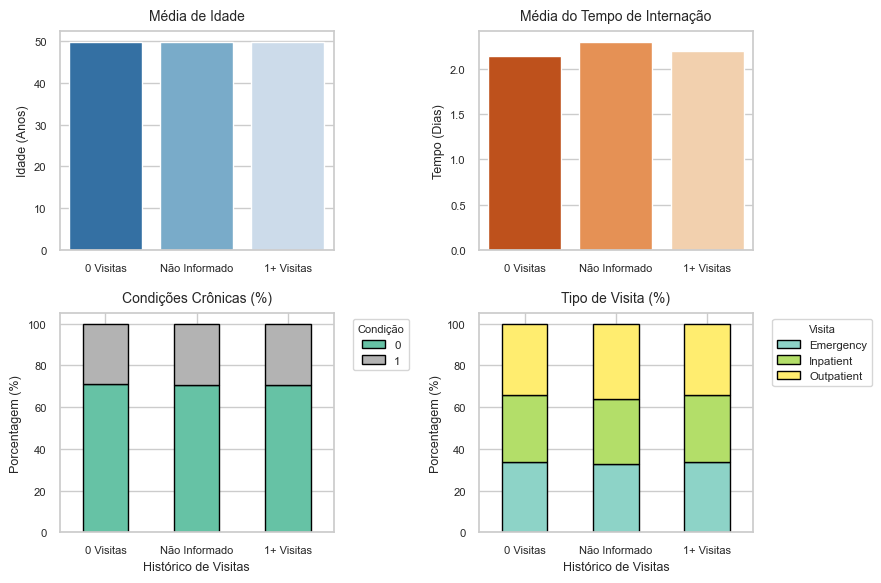

In [324]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Criação dos grupos com nomes amigáveis (sem underscores)
condicoes = [
    df['Visitas Anteriores nos Últimos 12 Meses'] == 0,
    df['Visitas Anteriores nos Últimos 12 Meses'].isna(),
    df['Visitas Anteriores nos Últimos 12 Meses'] > 0
]

# ---> ALTERAÇÃO AQUI: Nomes limpos para o eixo X <---
valores = ['0 Visitas', 'Não Informado', '1+ Visitas']

df['Grupo Analise'] = np.select(condicoes, valores, default='Outros')

# Configuração de estilo visual para os gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# ---------------------------------------------------------
# Gráfico 1: Média de Idade por Grupo
# ---------------------------------------------------------
analise_numerica = df.groupby('Grupo Analise')[['Idade do Paciente', 'Tempo de Internação']].mean().reset_index()

# Garantir a ordem lógica no gráfico
ordem_grupos = ['0 Visitas', 'Não Informado', '1+ Visitas', 'Outros']
ordem_presente = [g for g in ordem_grupos if g in analise_numerica['Grupo Analise'].values]

sns.barplot(data=analise_numerica, x='Grupo Analise', y='Idade do Paciente', ax=axes[0, 0], palette='Blues_r', order=ordem_presente)
axes[0, 0].set_title('Média de Idade', fontsize=10, pad=8)
axes[0, 0].set_ylabel('Idade (Anos)', fontsize=9)
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(labelsize=8)

# ---------------------------------------------------------
# Gráfico 2: Média do Tempo de Internação por Grupo
# ---------------------------------------------------------
sns.barplot(data=analise_numerica, x='Grupo Analise', y='Tempo de Internação', ax=axes[0, 1], palette='Oranges_r', order=ordem_presente)
axes[0, 1].set_title('Média do Tempo de Internação', fontsize=10, pad=8)
axes[0, 1].set_ylabel('Tempo (Dias)', fontsize=9)
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(labelsize=8)

# ---------------------------------------------------------
# Gráfico 3: Proporção de Condições Crônicas (Barras Empilhadas)
# ---------------------------------------------------------
cronicos_por_grupo = pd.crosstab(df['Grupo Analise'], df['Indicador de Condição Crônica'], normalize='index') * 100
# Reordenar as linhas para manter a consistência visual
cronicos_por_grupo = cronicos_por_grupo.reindex(ordem_presente)

cronicos_por_grupo.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap='Set2', edgecolor='black')

axes[1, 0].set_title('Condições Crônicas (%)', fontsize=10, pad=8)
axes[1, 0].set_ylabel('Porcentagem (%)', fontsize=9)
axes[1, 0].set_xlabel('Histórico de Visitas', fontsize=9)
axes[1, 0].tick_params(axis='x', rotation=0, labelsize=8) # Rotação em 0 pois os nomes agora são mais curtos
axes[1, 0].tick_params(axis='y', labelsize=8)
axes[1, 0].legend(title='Condição', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small', title_fontsize='8')

# ---------------------------------------------------------
# Gráfico 4: Distribuição do Tipo de Visita (Barras Empilhadas)
# ---------------------------------------------------------
visita_por_grupo = pd.crosstab(df['Grupo Analise'], df['Tipo de Visita'], normalize='index') * 100
visita_por_grupo = visita_por_grupo.reindex(ordem_presente)

visita_por_grupo.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='Set3', edgecolor='black')

axes[1, 1].set_title('Tipo de Visita (%)', fontsize=10, pad=8)
axes[1, 1].set_ylabel('Porcentagem (%)', fontsize=9)
axes[1, 1].set_xlabel('Histórico de Visitas', fontsize=9)
axes[1, 1].tick_params(axis='x', rotation=0, labelsize=8)
axes[1, 1].tick_params(axis='y', labelsize=8)
axes[1, 1].legend(title='Visita', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small', title_fontsize='8')

# ---------------------------------------------------------
# Ajustes finais e plotagem
# ---------------------------------------------------------
plt.tight_layout()
plt.show()

# Limpeza da coluna temporária
df.drop(columns=['Grupo Analise'], inplace=True)

Conclusão: a quantidade de visitas é uma contagem totalmente aleatória, não possui relação com outros atributos do dataset. Mas é interessante observar também a destribuição média dos valores, indicando que possivelmente nosso dataset é artificial.

In [325]:
moda = df['Visitas Anteriores nos Últimos 12 Meses'].mode()[0]
print(f"A moda da coluna 'Visitas Anteriores nos Últimos 12 Meses' é: {moda}")

A moda da coluna 'Visitas Anteriores nos Últimos 12 Meses' é: 3.0


### Tratamento dos dados
Etapa para tratar nulos, padronizar, transformar de inglês para português.

In [326]:
#Transformação em saída booleana da coluna de Fraude
df['É Fraude'] = df['É Fraude'].astype(bool)

print("Valores únicos na coluna 'É Fraude' após padronização:")
display(df['É Fraude'].unique())

Valores únicos na coluna 'É Fraude' após padronização:


array([False,  True])

In [327]:
df['Indicador de Condição Crônica'] = df['Indicador de Condição Crônica'].astype(bool)

print("Valores únicos na coluna 'Indicador de Condição Crônica' após padronização:")
display(df['Indicador de Condição Crônica'].unique())

Valores únicos na coluna 'Indicador de Condição Crônica' após padronização:


array([ True, False])

In [328]:
df['Especialidade do Prestador'] = df['Especialidade do Prestador'].fillna('Não informado')

print("Valores únicos na coluna 'Especialidade do Prestador' após o preenchimento:")
display(df['Especialidade do Prestador'].unique())

Valores únicos na coluna 'Especialidade do Prestador' após o preenchimento:


<StringArray>
[       'Cardiology',  'General Practice',       'Pulmonology',
       'Orthopedics',     'Não informado', 'Internal Medicine',
         'Neurology']
Length: 7, dtype: str

In [329]:
df['Tipo de Seguro'] = df['Tipo de Seguro'].fillna('Não informado')

print("Valores únicos na coluna 'Tipo de Seguro' após o preenchimento:")
display(df['Tipo de Seguro'].unique())

Valores únicos na coluna 'Tipo de Seguro' após o preenchimento:


<StringArray>
['Medicaid', 'Self-Pay', 'Private', 'Medicare', 'Não informado']
Length: 5, dtype: str

Tradução de valores para português

In [330]:
specialty_translation = {
    'Cardiology': 'Cardiologia',
    'General Practice': 'Clínica Geral',
    'Pulmonology': 'Pneumologia',
    'Orthopedics': 'Ortopedia',
    'Internal Medicine': 'Medicina Interna',
    'Neurology': 'Neurologia',
    'Não informado': 'Não informado' # Keep 'Não informado' as is
}

df['Especialidade do Prestador'] = df['Especialidade do Prestador'].map(specialty_translation)

print("Valores únicos na coluna 'Especialidade do Prestador' após a tradução:")
display(df['Especialidade do Prestador'].unique())

Valores únicos na coluna 'Especialidade do Prestador' após a tradução:


<StringArray>
[     'Cardiologia',    'Clínica Geral',      'Pneumologia',
        'Ortopedia',    'Não informado', 'Medicina Interna',
       'Neurologia']
Length: 7, dtype: str

In [331]:
genero_traduzido = {
    'Male': 'Masculino',
    'Female': 'Feminino',
    # Se houverem valores nulos, eles podem ser mapeados para 'Não informado'
    None: 'Não informado',
    'nan': 'Não informado' # Em caso de NaN como string
}

df['Gênero do Paciente'] = df['Gênero do Paciente'].map(genero_traduzido).fillna('Não informado')

print("Valores únicos na coluna 'Gênero do Paciente' após a tradução:")
display(df['Gênero do Paciente'].unique())

Valores únicos na coluna 'Gênero do Paciente' após a tradução:


<StringArray>
['Masculino', 'Feminino']
Length: 2, dtype: str

In [332]:
visit_type_translation = {
    'Outpatient': 'Ambulatorial',
    'Emergency': 'Emergência',
    'Inpatient': 'Internação'
}

df['Tipo de Visita'] = df['Tipo de Visita'].map(visit_type_translation)

print("Valores únicos na coluna 'Tipo de Visita' após a tradução:")
display(df['Tipo de Visita'].unique())

Valores únicos na coluna 'Tipo de Visita' após a tradução:


<StringArray>
['Ambulatorial', 'Internação', 'Emergência']
Length: 3, dtype: str

In [333]:
insurance_type_translation = {
    'Medicaid': 'Medicaid',
    'Self-Pay': 'Pagamento Direto',
    'Private': 'Privado',
    'Medicare': 'Medicare'
}

df['Tipo de Seguro'] = df['Tipo de Seguro'].map(insurance_type_translation)

print("Valores únicos na coluna 'Tipo de Seguro' após a tradução:")
display(df['Tipo de Seguro'].unique())

Valores únicos na coluna 'Tipo de Seguro' após a tradução:


<StringArray>
['Medicaid', 'Pagamento Direto', 'Privado', 'Medicare', nan]
Length: 5, dtype: str

In [334]:
status_solicitacao_translation = {
    'Approved': 'Aprovado',
    'Pending': 'Pendente',
    'Rejected': 'Rejeitado'
}

df['Status da Solicitação'] = df['Status da Solicitação'].map(status_solicitacao_translation)

print("Valores únicos na coluna 'Status da Solicitação' após a tradução:")
display(df['Status da Solicitação'].unique())

Valores únicos na coluna 'Status da Solicitação' após a tradução:


<StringArray>
['Aprovado', 'Pendente', 'Rejeitado']
Length: 3, dtype: str

Pelo fato dos valores faltantes de ['Visitas Anteriores nos Últimos 12 Meses'] representarem menos de 5% do dataset, a melhor prática nesse caso foi excluir as linhas nulas.

In [335]:
df.dropna(subset=['Visitas Anteriores nos Últimos 12 Meses'], inplace=True)

In [336]:
#Verificação de nulos por coluna

print("Número de valores nulos por coluna:")
display(df.isnull().sum())

print("Total de valores nulos no DataFrame:")
#print(df.isnull().sum().sum())

Número de valores nulos por coluna:


É Fraude                                           0
Idade do Paciente                                  0
Gênero do Paciente                                 0
Código de Diagnóstico                              0
Código do Procedimento                             0
Valor da Solicitação                               0
Valor Aprovado                                     0
Tipo de Seguro                                   338
Data de Envio da Solicitação                       0
Dias Entre o Atendimento e a Solicitação           0
Número de Solicitações por Prestador (Mensal)      0
Especialidade do Prestador                         0
Estado do Paciente                                 0
Status da Solicitação                              0
Tempo de Internação                                0
Tipo de Visita                                     0
Indicador de Condição Crônica                      0
Visitas Anteriores nos Últimos 12 Meses            0
dtype: int64

Total de valores nulos no DataFrame:


In [337]:
#Padranização de tipos
tipos_dados = {
    'É Fraude': 'boolean',
    'Indicador de Condição Crônica': 'boolean',
    'Código de Diagnóstico': 'category',
    'Código do Procedimento': 'category',
    'Idade do Paciente': 'int8',
    'Tempo de Internação': 'int8',
    'Visitas Anteriores nos Últimos 12 Meses': 'int16',
    'Gênero do Paciente': 'category',
    'Especialidade do Prestador': 'category',
    'Tipo de Visita': 'category',
    'Tipo de Seguro': 'category',
    'Status da Solicitação': 'category'
}

df = df.astype(tipos_dados)

In [338]:
df.info()

<class 'pandas.DataFrame'>
Index: 9650 entries, 0 to 9998
Data columns (total 18 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   É Fraude                                       9650 non-null   boolean       
 1   Idade do Paciente                              9650 non-null   int8          
 2   Gênero do Paciente                             9650 non-null   category      
 3   Código de Diagnóstico                          9650 non-null   category      
 4   Código do Procedimento                         9650 non-null   category      
 5   Valor da Solicitação                           9650 non-null   float64       
 6   Valor Aprovado                                 9650 non-null   float64       
 7   Tipo de Seguro                                 9312 non-null   category      
 8   Data de Envio da Solicitação                   9650 non-null   datetime64[

In [339]:
#df.to_excel('../data/dataset_tratado.xlsx', index=False)

Pré processamento de dados

In [340]:
colunas_num_padrao = [
    'Idade do Paciente',
    'Dias Entre o Atendimento e a Solicitação',
    'Número de Solicitações por Prestador (Mensal)',
    'Tempo de Internação',
    'Visitas Anteriores nos Últimos 12 Meses',
    'Indicador de Condição Crônica'

]

colunas_num_fincanceiro = [
    'Valor da Solicitação',
    'Valor Aprovado'
]

colunas_alta_cardinalidade = [
    'Código de Diagnóstico',
    'Código do Procedimento'
]

colunas_categoricas = [
    'Gênero do Paciente',
    'Tipo de Seguro',
    'Especialidade do Prestador',
    'Estado do Paciente',
    'Status da Solicitação',
    'Tipo de Visita'
]

In [341]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

In [342]:
pipe_num_padrao = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


pipe_num_financeiro = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])


pipe_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Desconhecido')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


pipe_alta_cardinalidade = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Desconhecido')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=0.02, sparse_output=False))
])

processador_de_dados = ColumnTransformer(
    transformers=[
        ('num_padrao', pipe_num_padrao, colunas_num_padrao),
        ('num_fin', pipe_num_financeiro, colunas_num_fincanceiro),
        ('cat', pipe_categorico, colunas_categoricas),
        ('cat_alta', pipe_alta_cardinalidade, colunas_alta_cardinalidade)
    ],
    remainder='drop'
)

In [343]:
processador_de_dados = ColumnTransformer(
    transformers=[
        ('num_padrao', pipe_num_padrao, colunas_num_padrao),
        ('num_fin', pipe_num_financeiro, colunas_num_fincanceiro),
        ('cat', pipe_categorico, colunas_categoricas),
        ('cat_alta', pipe_alta_cardinalidade, colunas_alta_cardinalidade) # Use the corrected list
    ],
    remainder='drop'
)

### Separação treino/teste
Após a etapa de tratamento dos dados, foi realizada a separação do dataset entre treino e teste. Primeiro, foram criados dois subconjuntos: X e y. O subconjunto X contém todas as variáveis de entrada do modelo, ou seja, todas as colunas do dataset, exceto a coluna 'É Fraude'. Já o subconjunto y contém apenas a coluna target 'É Fraude', que indica se um registro corresponde ou não a uma fraude.

Em seguida, foi utilizada a função `train_test_split()` realizar a divisão dos dados. Foi definido test_size=0.2, indicando que 20% dos registros seriam separados para teste e 80% utilizados para treino, proporção amplamente recomendada em projetos de Machine Learning.

Também foi utilizado o parâmetro random_state=42, responsável por definir uma semente aleatória fixa para a divisão dos dados. Isso garante que a separação ocorra sempre da mesma forma em futuras execuções, permitindo reproduzir os mesmos resultados e facilitando a análise das métricas do modelo.

Como resultado, foram gerados quatro subconjuntos:

X_train e y_train, utilizados no treinamento;
X_test e y_test, utilizados na validação e teste do modelo.

In [344]:
X = df.drop('É Fraude', axis=1)
y = df['É Fraude']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_treino_processado = processador_de_dados.fit_transform(X_treino)
X_teste_processado = processador_de_dados.transform(X_teste)

print(f"Formato original dos dados de treino: {X_treino.shape}")
print(f"Formato final após o processamento (matriz para a Rede Neural): {X_treino_processado.shape}")

Formato original dos dados de treino: (7720, 17)
Formato final após o processamento (matriz para a Rede Neural): (7720, 55)


In [345]:
print(X["Data de Envio da Solicitação"])

0      2024-09-01
1      2022-09-05
2      2022-04-11
3      2023-10-11
4      2023-09-05
          ...    
9994   2024-01-22
9995   2024-09-24
9996   2023-01-04
9997   2024-06-30
9998   2022-03-15
Name: Data de Envio da Solicitação, Length: 9650, dtype: datetime64[us]


### Balanceamento de classes

Como nosso dataset possui um desbalanceamento de classes, em que os registros de fraude representam uma parcela significativamente menor dos dados em relação aos casos não fraudulentos, foi necessário aplicar uma técnica de balanceamento durante o treinamento da rede neural.

Esse desbalanceamento pode fazer com que o modelo aprenda a priorizar a classe majoritária, reduzindo sua capacidade de identificar corretamente os casos de fraude. Em problemas desse tipo, esse comportamento é crítico, pois aumenta a ocorrência de falsos negativos, situação em que uma fraude é classificada incorretamente como não fraude.

In [346]:
classes = np.unique(y_treino)

pesos = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_treino
)

class_weight = dict(zip(classes, pesos))

print(class_weight)

{np.False_: np.float64(0.5451977401129944), np.True_: np.float64(6.03125)}


### Testes com parâmetros
Esta seção apresenta experimentos realizados com diferentes configurações da rede neural. Podemos alterar quantidade de neurônios, número de camadas ocultas, taxa de aprendizado ou quantidade de épocas e comparar os resultados obtidos. O objetivo é demonstrar como os parâmetros influenciam o desempenho do modelo.

In [347]:
experimentos = [
    {
        'nome': 'Baseline',
        'neuronios_camadas': [32],
        'learning_rate': 0.001,
        'optimizer_name': 'adam',
        'dropout_rate': 0.0
    },

    {
        'nome': 'Baseline_SGD',
        'neuronios_camadas': [32],
        'learning_rate': 0.01,
        'optimizer_name': 'sgd',
        'dropout_rate': 0.1
    },

    {
        'nome': 'Baseline_RMSprop',
        'neuronios_camadas': [32],
        'learning_rate': 0.001,
        'optimizer_name': 'rmsprop',
        'dropout_rate': 0.1
    },

    {
        'nome': 'Profunda',
        'neuronios_camadas': [64, 32],
        'learning_rate': 0.001,
        'optimizer_name': 'adam',
        'dropout_rate': 0.0
    },

    {
        'nome': 'Profunda_SGD',
        'neuronios_camadas': [64, 32],
        'learning_rate': 0.01,
        'optimizer_name': 'sgd',
        'dropout_rate': 0.0
    },

    {
        'nome': 'Profunda_RMSprop',
        'neuronios_camadas': [64, 32],
        'learning_rate': 0.001,
        'optimizer_name': 'rmsprop',
        'dropout_rate': 0.0
    },

    {
        'nome': 'Profunda_Dropout',
        'neuronios_camadas': [64, 32],
        'learning_rate': 0.001,
        'optimizer_name': 'adam',
        'dropout_rate': 0.2
    },

    {
        'nome': 'Grande',
        'neuronios_camadas': [128, 64, 32],
        'learning_rate': 0.001,
        'optimizer_name': 'adam',
        'dropout_rate': 0.3
    },

    {
        'nome': 'Grande_LR_Baixo',
        'neuronios_camadas': [128, 64, 32],
        'learning_rate': 0.0005,
        'optimizer_name': 'adam',
        'dropout_rate': 0.3
    }
]

In [348]:
resultados = []

for exp in experimentos:

    modelo = criar_modelo(
        input_dim=X_treino_processado.shape[1],
        neuronios_camadas=exp['neuronios_camadas'],
        learning_rate=exp['learning_rate'],
        optimizer_name=exp['optimizer_name'],
        dropout_rate=exp['dropout_rate']
    )

    historico = modelo.fit(
        X_treino_processado,
        y_treino,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        class_weight=class_weight,
        verbose=0
    )

    y_prob = modelo.predict(X_teste_processado)

    y_pred = (y_prob > 0.5).astype(int)

    accuracy = accuracy_score(y_teste, y_pred)
    precision = precision_score(y_teste, y_pred)
    recall = recall_score(y_teste, y_pred)
    f1 = f1_score(y_teste, y_pred)

    cm = confusion_matrix(
    y_teste,
    y_pred
    )

    tn, fp, fn, tp = cm.ravel()
    
    resultados.append({
        'Experimento': exp['nome'],
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })

c:\Users\tbastosdeoli\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


c:\Users\tbastosdeoli\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


c:\Users\tbastosdeoli\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


c:\Users\tbastosdeoli\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


c:\Users\tbastosdeoli\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


### Avaliação de Métricas
Explicar quais métricas escolhemos e o porquê.

Devemos mostrar o "Erro atingido no aprendizado".

In [349]:
df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by=['Recall','F1'],
    ascending=[False, False]
)

df_resultados

,Experimento,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
1,Baseline_SGD,0.948705,0.623482,0.96250,0.756757,1677,93,6,154
4,Profunda_SGD,0.965285,0.720379,0.95000,0.819407,1711,59,8,152
2,Baseline_RMSprop,0.965285,0.724638,0.93750,0.817439,1713,57,10,150
0,Baseline,0.977720,0.823204,0.93125,0.873900,1738,32,11,149
3,Profunda,0.981865,0.883436,0.90000,0.891641,1751,19,16,144
5,Profunda_RMSprop,0.977202,0.837209,0.90000,0.867470,1742,28,16,144
6,Profunda_Dropout,0.980311,0.871951,0.89375,0.882716,1749,21,17,143
8,Grande_LR_Baixo,0.972539,0.798883,0.89375,0.843658,1734,36,17,143
7,Grande,0.978756,0.888889,0.85000,0.869010,1753,17,24,136


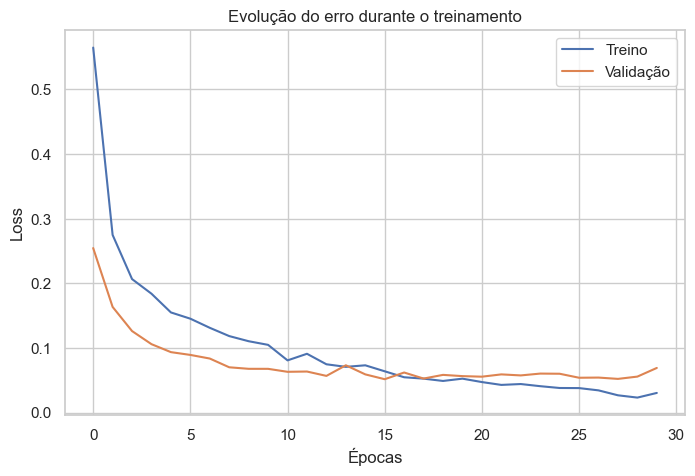

In [350]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    historico.history['loss'],
    label='Treino'
)

plt.plot(
    historico.history['val_loss'],
    label='Validação'
)

plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Evolução do erro durante o treinamento')
plt.legend()

plt.show()

### Criação, compilação e treinamento da RNA
Devemos mostrar "Número de iterações atingido no aprendizado" (épocas/epochs), "Taxa de aprendizado", "Número de camadas intermediárias" e "Neurônios das camadas intermediárias".

In [ ]:
modelo_final = criar_modelo(
    input_dim=X_treino_processado.shape[1],
    neuronios_camadas=[32],
    optimizer_name='sgd',
    learning_rate=0.01,
    dropout_rate=0.1 
)

modelo_final.fit(
    X_treino_processado,
    y_treino,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30


c:\Users\tbastosdeoli\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2848 - recall: 0.0368 - val_loss: 0.1743 - val_recall: 0.0565
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1428 - recall: 0.2791 - val_loss: 0.1170 - val_recall: 0.3952
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1038 - recall: 0.5930 - val_loss: 0.0948 - val_recall: 0.5806
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0860 - recall: 0.6841 - val_loss: 0.0809 - val_recall: 0.6774
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0783 - recall: 0.7345 - val_loss: 0.0713 - val_recall: 0.7177
Epoch 6/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0685 - recall: 0.7752 - val_loss: 0.0638 - val_recall: 0.7742
Epoch 7/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0647 - recall: 0.7868 - val_loss: 0.0575 - val_recall: 0.8145
Epoch 8/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0577 - recall: 0.8120 - val_loss: 0.0532 - val_recall: 0.8226
Epoch 9/30
193/193 

### Previsões
Aqui são realizados testes práticos utilizando entradas fornecidas manualmente. 

### Conclusão
Aqui vai a análise final sobre os resultados alcançados, se o objetivo foi atingido, quais dificuldades foram encontradas, quais limitações o modelo apresentou e possíveis melhorias futuras.